In [1]:
import numpy as np
import pandas as pd
# from scipy.interpolate import UnivariateSpline
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt
import os
import csv
import datetime as d
from datetime import datetime as D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random 
import time
import math
import scipy
from scipy import stats
from scipy.stats import norm
from scipy.optimize import curve_fit


In [2]:
%run ../codes/data_input.py
%run ../codes/mcmc_fun.py
%run ../codes/SEIVR.py
%run ../codes/curve_prepare.py

In [5]:
M_death_06_wk = np.loadtxt('deaths_06_phase2_v2.csv', delimiter=',')
# M_death_06_cum = np.cumsum(M_death_06_wk, axis=0)

In [6]:
M_death_06_wk[10:,:].shape

(56, 5)

In [7]:
death_m = np.zeros((9,5))
for m_i in range(9):
    check = M_death_06_wk[10+m_i*4:10+(m_i+1)*4,:]
    print(check.shape)
    death_m[m_i,:] = np.sum(check,axis=0)

(4, 5)
(4, 5)
(4, 5)
(4, 5)
(4, 5)
(4, 5)
(4, 5)
(4, 5)
(4, 5)


In [7]:
death_real_shape = np.zeros((4,5))
death_real_shape[0,:] = np.sum(death_m[:6,:],axis=0)
death_real_shape[1:,:] = death_m[6:6+3,:]

In [8]:
actural_inf_06 = (np.loadtxt('serology_infections_06_complete.csv')).reshape(3,5,18)

In [9]:
IFR_real_shape_06 = np.zeros((3,4,5)) ## month 3-8, 9 ,10, 11
new_month_inf_06 = np.diff(actural_inf_06,axis=2)
### mean value of IFR
for j in range(3):
    IFR_real_shape_06[j,0,:] = death_real_shape[0,:]/actural_inf_06[j,:,1]
    for i in range(1,4):
        IFR_real_shape_06[j,i,:] = death_real_shape[i,:]/new_month_inf_06[j,:,i+2]

In [21]:
IFR_real_shape_06[0]

array([[ 0.01610835,  0.018313  ,  0.01789287,  0.00845943,  0.01997988],
       [ 0.00791344,  0.00874651,  0.00423154,  0.02499388,  0.04966427],
       [ 0.00077759,  0.00473769, -0.00655497,  0.00188547,  0.00157831],
       [ 0.00086272,  0.00090814,  0.00067917,  0.00054078,  0.00605662]])

In [22]:
IFR_real_shape_06[1]

array([[ 0.03463296,  0.02877758,  0.08179596,  0.01582023,  0.05794165],
       [ 0.02110252,  0.00999601, -0.08463088,  0.01333007,  0.01773724],
       [ 0.00139649,  0.00568523,  0.00370498,  0.00314245,  0.00689782],
       [ 0.00154057,  0.00109569,  0.00240996,  0.00061999,  0.00886862]])

In [23]:
IFR_real_shape_06[2] 

array([[ 0.00532815,  0.0113489 ,  0.0029744 ,  0.0037831 ,  0.00351161],
       [ 0.00234472,  0.00608453,  0.00128229, -0.00833129,  0.00653477],
       [ 0.00067751,  0.00501638, -0.00056062,  0.00099987,  0.00075401],
       [ 0.00042016,  0.00074669,  0.00035746,  0.00052016,  0.00349748]])

In [10]:
my_ifr = np.array([[ 0.01610835,  0.018313  ,  0.01789287,  0.00845943,  0.01997988],
       [ 0.00791344,  0.00874651,  0.00423154,  0.02499388,  0.04966427],
       [ 0.00077759,  0.00473769, 0.00370498,  0.00188547,  0.00157831],
       [ 0.00086272,  0.00090814,  0.00067917,  0.00054078,  0.00605662]])

In [24]:
(IFR_real_shape_06[2] + IFR_real_shape_06[1])/2

array([[ 0.01998055,  0.02006324,  0.04238518,  0.00980166,  0.03072663],
       [ 0.01172362,  0.00804027, -0.0416743 ,  0.00249939,  0.01213601],
       [ 0.001037  ,  0.00535081,  0.00157218,  0.00207116,  0.00382591],
       [ 0.00098036,  0.00092119,  0.00138371,  0.00057007,  0.00618305]])

In [11]:
my_ifr_ts = np.zeros((28*9,5))
my_ifr_ts[:28*5] = my_ifr[0]
my_ifr_ts[28*5:28*6] = my_ifr[1]
my_ifr_ts[28*6:28*7] = my_ifr[2]
my_ifr_ts[28*7:28*8] = my_ifr[3]

In [114]:
np.savetxt('my_ifr_ts.csv',my_ifr_ts)

In [12]:
##### acculate death
death_real_shape = np.zeros((5,5))
death_real_shape[0,:] = np.sum(death_m[:5,:],axis=0)
death_real_shape[1:,:] = death_m[5:5+4,:].cumsum(axis=0)

IFR_real_shape_06 = np.zeros((3,5,5)) ## month 3-8, 9 ,10, 11

### mean value of IFR
for j in range(3):
    IFR_real_shape_06[j,0,:] = death_real_shape[0,:]/actural_inf_06[j,:,0]
    for i in range(1,5):
        IFR_real_shape_06[j,i,:] = death_real_shape[i,:]/actural_inf_06[j,:,i]

/var/folders/_0/2l3z2qss74scb88wvbv1szxr0000gn/T/ipykernel_74090/813807723.py:12: RuntimeWarning: divide by zero encountered in divide
  IFR_real_shape_06[j,i,:] = death_real_shape[i,:]/actural_inf_06[j,:,i]


In [28]:
IFR_real_shape_06[0]

array([[0.01112343, 0.01954116, 0.0246759 , 0.02267757, 0.03372265],
       [0.0036915 , 0.00498949, 0.00401267, 0.00247507, 0.0042814 ],
       [0.01426747, 0.0074892 ,        inf, 0.00397401, 0.00628662],
       [0.01310287, 0.00717355, 0.00415681, 0.00414665, 0.00935457],
       [0.00973213, 0.0069944 , 0.00359507, 0.0046615 , 0.01193853]])

In [29]:
IFR_real_shape_06[1]

array([[0.0333703 , 0.0325686 , 0.0807575 , 0.0410356 , 0.08277378],
       [0.00793672, 0.00784062, 0.01834364, 0.0046287 , 0.01241607],
       [0.07133737, 0.01159618,        inf, 0.00713283, 0.03547448],
       [0.03930861, 0.01058952, 0.01460821, 0.007482  , 0.0296906 ],
       [0.02789877, 0.00974221, 0.01775745, 0.00758038, 0.0251677 ]])

In [30]:
IFR_real_shape_06[2]

array([[0.0035595 , 0.01065881, 0.00285637, 0.00805372, 0.00387452],
       [0.00122103, 0.00309208, 0.00066704, 0.00110686, 0.00075249],
       [0.00306827, 0.00473002, 0.00147942, 0.00205299, 0.00105894],
       [0.00299811, 0.0049973 , 0.00089857, 0.00209861, 0.00224633],
       [0.00243303, 0.0048711 , 0.00083594, 0.0026681 , 0.00272282]])

In [16]:
my_ifr = np.array([[0.01112343, 0.01954116, 0.0246759 , 0.02267757, 0.03372265],
       [0.0036915 , 0.00498949, 0.00401267, 0.00247507, 0.0042814 ],
       [0.01426747, 0.0074892 , 0.00147942, 0.00397401, 0.00628662],
       [0.01310287, 0.00717355, 0.00415681, 0.00414665, 0.00935457],
       [0.00973213, 0.0069944 , 0.00359507, 0.0046615 , 0.01193853]])

In [17]:
my_ifr_ts = np.zeros((28*9,5))
my_ifr_ts[:28*5] = my_ifr[0]
my_ifr_ts[28*5:28*6] = my_ifr[1]
my_ifr_ts[28*6:28*7] = my_ifr[2]
my_ifr_ts[28*7:28*8] = my_ifr[3]
my_ifr_ts[28*8:28*9] = my_ifr[4]

In [178]:
np.savetxt('my_ifr_ts-v2.csv',my_ifr_ts)

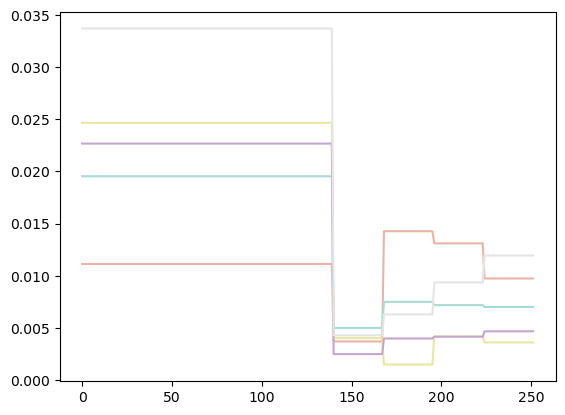

In [33]:
for r_idx in range(5):
    r = race_list_06[r_idx]
    plt.plot(my_ifr_ts[:,r_idx],label=r,c=custom_colors[r])

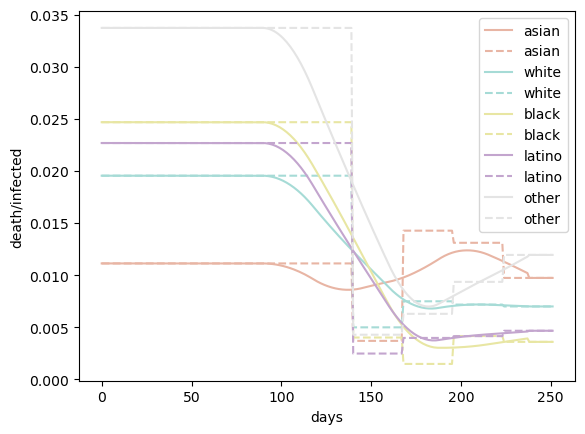

In [18]:
from scipy.signal import savgol_filter
def moving_average(data, window_size):
    """ Compute moving average """
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')
def exponential_moving_average(data, alpha):
    """ Compute exponential moving average """
    ema = []
    for point in data:
        if not ema:
            ema.append(point)
        else:
            ema.append(alpha * point + (1 - alpha) * ema[-1])
    return np.array(ema)
temp_v3 = np.zeros_like(my_ifr_ts) 
for r_idx in range(5):
    r = race_list_06[r_idx]
    # temp = moving_average(my_ifr_ts[:,r_idx],28)
    temp = savgol_filter(my_ifr_ts[:,r_idx], window_length=70, polyorder=1)
    temp2 = moving_average(temp,28)
    temp3 = np.zeros(my_ifr_ts.shape[0])
    temp3[13:-14] = temp2
    temp3[:14] = temp[:14]
    temp3[-14:] = my_ifr_ts[-14:,r_idx]
    temp_v3[:,r_idx] = temp3
    # temp = exponential_moving_average(my_ifr_ts[:,r_idx],0.5)
    # plt.plot(temp,label=r,c=custom_colors[r])
    plt.plot(temp3,label=r,c=custom_colors[r])
    # plt.plot(temp2,label=r,c=custom_colors[r])
    plt.plot(my_ifr_ts[:,r_idx],'--',label=r,c=custom_colors[r])
    plt.ylabel('death/infected')
    plt.xlabel('days')
plt.legend()

In [37]:
np.savetxt('my_ifr_ts-v4_06.csv',temp_v3)